<a href="https://colab.research.google.com/github/0987-k123/Machine-learning-/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("/content/USArrests.csv")

# Display first few rows
print(df.head())

# Check dataset information
print(df.info())

# Separate features and target (dropping 'State' for PCA, as there's no 'class' column)
X = df.drop('State', axis=1) # Drop 'State' as it's not a numerical feature for PCA
# Removed y = df['class'] as 'class' column does not exist.

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for PCA results
pca_df = pd.DataFrame(
    data=X_pca,
    columns=['Principal Component 1', 'Principal Component 2']
)

# Add State column for context, as there's no 'target' class
pca_df['State'] = df['State']

# Explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(np.sum(pca.explained_variance_ratio_))

# Plot PCA
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='Principal Component 1',
    y='Principal Component 2',
    hue='State', # Changed 'target' to 'State' for visualization
    palette='Set1',
    s=80
)

plt.title("/content/USArrests.csv")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

        State  Murder  Assault  UrbanPop  Rape
0     Alabama    13.2      236        58  21.2
1      Alaska    10.0      263        48  44.5
2     Arizona     8.1      294        80  31.0
3    Arkansas     8.8      190        50  19.5
4  California     9.0      276        91  40.6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   State     50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB
None


KeyError: "['class'] not found in axis"

In [4]:
from sklearn.cluster import KMeans

# Determine optimal number of clusters (e.g., using Elbow Method or just pick one for now)
# For demonstration, let's assume 3 clusters for the USArrests dataset
n_clusters = 3

# Apply K-Means clustering to the scaled data
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init is set to 10 to suppress future warnings
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the PCA DataFrame
pca_df['Cluster'] = clusters

# Display the first few rows with clusters
print("PCA DataFrame with Clusters:")
display(pca_df.head())

# Plot PCA with K-Means clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster', # Use 'Cluster' for coloring
    palette='viridis', # Choose a different palette for clusters
    s=100,
    alpha=0.8,
    style='Cluster' # Add style to differentiate clusters
)

# Annotate points with State names
for i, state in enumerate(pca_df['State']):
    plt.text(pca_df['Principal Component 1'][i] * 1.02, pca_df['Principal Component 2'][i] * 1.02, state, fontsize=8)

plt.title(f'PCA of USArrests with K-Means Clustering (k={n_clusters})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

NameError: name 'X_scaled' is not defined

Correlation Matrix:


,Murder,Assault,UrbanPop,Rape
Murder,1.000000,0.801873,0.069573,0.563579
Assault,0.801873,1.000000,0.258872,0.665241
UrbanPop,0.069573,0.258872,1.000000,0.411341
Rape,0.563579,0.665241,0.411341,1.000000


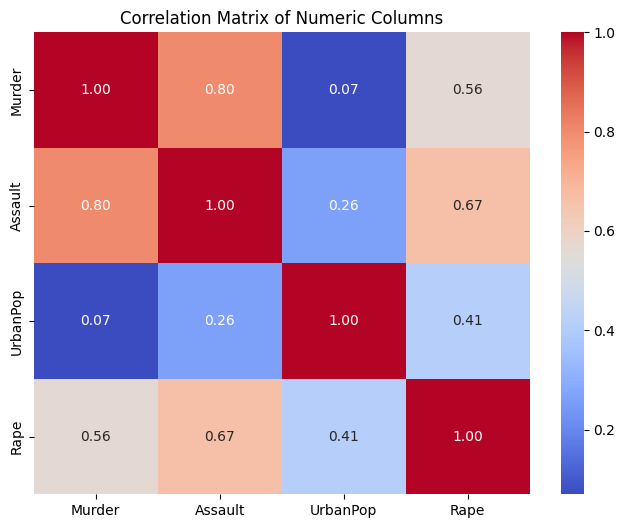

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numeric columns
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Optionally, visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Columns')
plt.show()